# **Single-Channel Speech Separation** 
### ($2^{nd}$ Homework)
---

### Problem Formulation

Given a known *mixture signal* $x = (x[0],\,\dots,\, x[T-1]) \in \mathbb{R}^T$ obtained by mixing $C$ sources $s_i \in \mathbb{R}^T,\, i \in \{0,\, \dots,\, C-1\}$ as follows:
$$x[n] = \sum_{i=0}^{C-1} s_i[n], \, \forall \,n \in \{0,\, \dots,\, T-1\}$$
we are interested in estimating source signals $s_i$, given only $x$.

<div style="text-align: center;">
  <img src="imgs/speech_sep.png" alt="description" width="1000"/>
  <figcaption><a href=https://arxiv.org/pdf/2111.08635.pdf>Source</a></figcaption>
</div>

---

### Use-case: Two-Speaker Separation with `MiniLibriMix` dataset

The [LibriMix](https://inria.hal.science/hal-03354695/document) dataset consists of two- or three-speaker mixtures combined (or not) with ambient noise samples. 

We'll use a smaller version of it, namely [MiniLibri2Mix](https://zenodo.org/records/3871592), with two-speaker mixtures, containing 800 mixtures for training and 200 for validation / testing.

Run the code below to download and extract the data:

In [1]:
import requests, zipfile, io, logging
from tqdm import tqdm
import os

zip_file_url = "https://zenodo.org/records/3871592/files/MiniLibriMix.zip?download=1"

def download_with_progress(url, destination):
    response = requests.get(url, stream=True)
    total_size_in_bytes = int(response.headers.get('content-length', 0))
    block_size = 1024 * 1024 * 10   # 10MB

    with open(destination, 'wb') as file, tqdm(
            desc=destination,
            total=total_size_in_bytes,
            unit='iB',
            unit_scale=True,
            unit_divisor=1024,
    ) as bar:
        for data in response.iter_content(block_size):
            file.write(data)
            bar.update(len(data))

if not os.path.exists("./MiniLibriMix.zip"):
    download_with_progress(zip_file_url, "./MiniLibriMix.zip")

if not os.path.exists("./data/mini_libri2mix"):
    with zipfile.ZipFile("./MiniLibriMix.zip", 'r') as z:
        z.extractall("./data/mini_libri2mix")

./MiniLibriMix.zip: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 611M/611M [01:08<00:00, 9.34MiB/s]


#### Define LibriMix Dataset

We'll need a class that can access the MiniLibriMix dataset files and segment each to a given `segment_length`, passed as an argument. We need a dataset that would return segments of a specified `segment_length` (in seconds) of the form `(mixture, s_1, s_2)`.

In [3]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import os
import pandas as pd
import librosa
from IPython.display import Audio, display
import matplotlib.pyplot as plt


class LibriMixDataset(Dataset):
    def __init__(self, root, subset="train", segment_length=3, typ="clean", sample_rate=8000):
        """
        :param root: string, path to the folder containing MiniLibriMix directory
        :param subset: string, either "train" or "val"
        :param segment_length: float, the length of each sample in seconds
        :param typ: string, either "clean" for non-noisy mixtures, or "both" which includes the background noise
        """

        self.root = root
        self.subset = subset
        self.typ = typ
        self.sample_rate = sample_rate

        self.seg_len = segment_length * self.sample_rate
        
        assert self.subset in ["train", "val"]
        assert self.typ in ["clean", "both"]

        self.mixtures_path = os.path.join(self.root, 
                                          "MiniLibriMix",
                                          self.subset,
                                          f"mix_{self.typ}",)

        self.metadata_path = os.path.join(self.root, "MiniLibriMix/metadata", f"mixture_{self.subset}_mix_{self.typ}.csv")
        self.metadata = pd.read_csv(self.metadata_path)

        self.segments_per_file = self._segs_per_file()

        # We'll create a list of mixture paths, each one repeated by the number of segments it contains (and the limits for each segment)
        # This will help when indexing the dataset -- we'll know which file to read and from which timestamps to segment
        self.mixtures = []
        for m, k in self.segments_per_file.items():
            for i in range(k):
                self.mixtures.append(
                    (m, i * self.seg_len, (i + 1) * self.seg_len)  # (mixture_path, start_index, end_index)
                )

    def _segs_per_file(self):
        """
        Returns a dictionary with keys : <mixture file path> and values : <#segments per file>.
        This will help in assessing the dataset length (internally used by DataLoader to batch samples) and in constructing the
        mixtures list from which we'll sample given an index (key).
        """
        length_dict = {}
        for index, row in self.metadata.iterrows():
            mixture_path = row['mixture_path']
            length = row['length']
            if length < self.seg_len:
                length_dict[mixture_path] = 1   # we'll pad this with 0s
            else:
                length_dict[mixture_path] = int(length // self.seg_len)
    
        return length_dict

    def __len__(self):
        return sum(list(self.segments_per_file.values()))

    def __getitem__(self, key):
        """
        Retrieves the mixture and sources segments.
        """
        mix_path, sources_path, timestamps = self._get_metadata(key)

        start, end = timestamps
        
        mix, sr = librosa.load(mix_path, sr=self.sample_rate)
        mix = mix[start: end]
        sources = []
        for s_path in sources_path:
            source, sr = librosa.load(s_path, sr=self.sample_rate)
            source = source[start: end]
            sources.append(source)
        
        return mix, torch.FloatTensor(np.array(sources))

    def listen_samples(self, key):
        """
        Retrieves signal paths and plots waveform/audio widget.
        """
        mix_path, sources_path, timestamps = self._get_metadata(key)
        
        start, end = timestamps
        
        audio_files = [mix_path] + sources_path
        audio_titles = ['Mix', 'Source 1', 'Source 2']
        
        audio_widget_groups = []
        for audio_file, title in zip(audio_files, audio_titles):
            
            # Load the audio file and extract the signal and sampling rate
            signal, sr = librosa.load(audio_file, sr=self.sample_rate)

            signal = signal[start: end]
            # Plot the waveform
            plt.figure(figsize=(10, 1))
            librosa.display.waveshow(signal, sr=self.sample_rate)
            plt.title(title)
            plt.xlabel('Time (s)')
            plt.ylabel('Amplitude')
            plt.ylim([-1, 1])
            plt.show()
            
            # Display the audio player
            display(Audio(data=signal, autoplay=False, rate=self.sample_rate))
    
    def _get_metadata(self, key):
        """
        Retrieves the paths for one element of the dataset:
            - mixture
            - source 1
            - source 2

        And returns these paths along with the start-end timestamps
        """
        
        mixture_path, start, end = self.mixtures[key]

        row = self.metadata[self.metadata["mixture_path"] == mixture_path]
        s1_path = row["source_1_path"].values[0]
        s2_path = row["source_2_path"].values[0]

        mixture_path = os.path.join(self.root, mixture_path)
        s1_path = os.path.join(self.root, s1_path)
        s2_path = os.path.join(self.root, s2_path)
        
        return mixture_path, [s1_path, s2_path], (start, end)

In [4]:
segment_length = 3
sr = 8000

train_ds = LibriMixDataset(root="./data/mini_libri2mix/", 
                           subset="train", 
                           segment_length=segment_length, 
                           typ="clean", 
                           sample_rate=sr)

val_ds = LibriMixDataset(root="./data/mini_libri2mix/", 
                         subset="val", 
                         segment_length=segment_length, 
                         typ="clean", 
                         sample_rate=sr)

In [5]:
print(f"#train samples: {len(train_ds)} \t #val_samples: {len(val_ds)}")

#train samples: 2499 	 #val_samples: 277


View & listen to some samples:

('./data/mini_libri2mix/MiniLibriMix/val/mix_clean/7976-105575-0011_7850-281318-0011.wav', ['./data/mini_libri2mix/MiniLibriMix/val/s1/7976-105575-0011_7850-281318-0011.wav', './data/mini_libri2mix/MiniLibriMix/val/s2/7976-105575-0011_7850-281318-0011.wav'], (0, 24000))
(24000,)
torch.Size([24000])
torch.Size([24000])


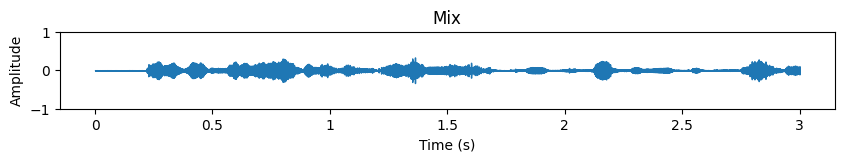

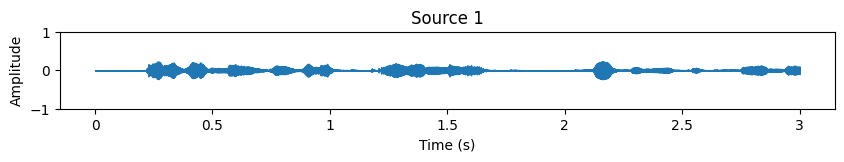

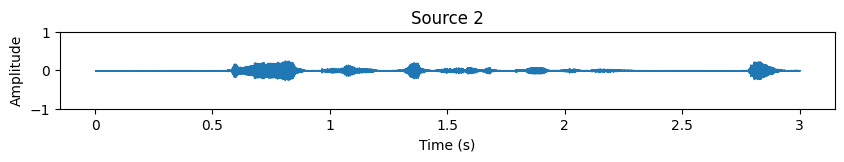

In [6]:
import numpy as np

i = np.random.randint(0, len(val_ds))

print(val_ds._get_metadata(i))

mix, sources = val_ds[i]
print(mix.shape)
for s in sources:
    print(s.shape)

val_ds.listen_samples(i)

### **Conv-TasNet**: *Surpassing Ideal Time-Frequency Magnitude Masking for Speech Separation*

We'll use the [Conv-TasNet](https://arxiv.org/pdf/1809.07454v3.pdf) fully-convolutional architecture, using a linear encoder (1D Conv) to map the input mixture to a learned representation, followed by masking the output through a *Temporal Convolutional Network*, and finally retrieving the source signals by inverting the masked representations through a linear decoder (see below).

<div style="text-align: center;">
  <img src="imgs/CONVTASNET.png" alt="description" width="1000"/>
  <figcaption><a href=https://arxiv.org/pdf/1809.07454v3.pdf>Source</a></figcaption>
</div>

Let's break it down:
1. **Encoder**
    - Tramsforms the input mixture signal using a 1D Conv operation + ReLU
    - The output can be computed as: $y_E = ReLU(W_E \circledast X)$
    - $W_E$ encapsulates the 1D filters of the Encoder, and $X$ is the input mixture signal
2. **Separation**
     - The separation module computes $C$ masks $m_i \in [0, 1]^L$, where $C$ is the number of speakers
     - The representation of each source signal is then computed as: $d_i = y_e \odot m_i$, where $\odot$ denotes element-wise multiplication
     - The constraint $\sum_{i=1}^C m_i = 1$ is aplied during training, assuming the network could perfectly reconstruct the input mixture
     - The separation module conists of multiple stacked 1D Convolution blocks with increasing *dilation rates* -- a lerger dilation rate indicates that a larger temporal context is taken into account for each window of convolution
     - $M$ such convolutional blocks are stacked (with dilation rates $\{1, \dots, 2^{M-1}\}$), and this stacking is repeated $R$ times, with zero-padding applied at the entrance of each block to ensure same output length (to be able to sum up all of them)
3. **Decoder**
   - The masked representation is brought back to the dimension of the original signal $X$, through *Transposed Convolution* (see below an example)
   - Each masked source representation $d_i$ is transferred to the input domain by: $\hat{s_i} = d_i \circledast^T W_D$


**Dilated Convolutions**, used in the Separation module, are a type of convolution where the filter is *widened* with a *dilation factor* $d>1$. For $d=1$ the standard convolution is obtained. 

<div style="text-align: center;">
  <img src="imgs/dilated.png" alt="description" width="500"/>
  <figcaption><a href=https://www.researchgate.net/publication/338780378/figure/fig1/AS:850664980742144@1579825744895/The-illustration-of-the-2D-dilated-convolution-with-spatial-size-of-33-and-dilation.png>Source</a></figcaption>
</div>

In the figure above, a dilation factor $d=2$ introduces a zero (a green cells) between two adjacent weights, increasing the effective receptive field from $3\times 3$ to $5\times 5$ -- more generally, for a $k\times k$ kernel and dilation factor $d$ the resulted receptive field becomes $(k + (k-1)(d-1)) \times (k + (k-1)(d-1))$.

This means that for same-sized kernels, an increasing dilation factor $d$ would *"look"* at a bigger area in the input image, at each step. They're useful at extracting multi-scale features, an also very efficient when dealing with very high-resolution images (where small, e.g. $3\times 3$, areas are approximately uniform).

**Transposed Convolution** also known as deconvolution, is a mathematical operation used to increase the spatial/temporal resolution of a signal/internal representation. In a regular convolution, you move the filter over the image, multiply the values of the filter by the corresponding pixel values of the image, and add them together to create a new value. For transposed convolution, instead of moving the filter over the image, you expand the image by inserting empty spaces between its pixels, and then you apply the filter to this expanded image.

<div style="text-align: center;">
  <img src="imgs/tconv.png" alt="description" width="1000"/>
  <figcaption><a href=https://www.geeksforgeeks.org/what-is-transposed-convolutional-layer>Source</a></figcaption>
</div>

### Implementing Conv-TasNet

We'll need to define three modules: `Encoder`, `Decoder` and `SeparationModule`. These three will be encapsulated in a single class defining the full `ConvTasNet` architecture. The structure of our implementation will be based on the one presented [here](https://github.com/kaituoxu/Conv-TasNet/blob/master/src/conv_tasnet.py).

In [8]:
class Encoder(nn.Module):
    def __init__(self, L, N):
        """
        :param L: kernel/filter size
        :param N: number of kernels for Conv1d
        """
        super(Encoder, self).__init__()
        
        self.L, self.N = L, N
        self.conv1d = nn.Conv1d(1, N, kernel_size=L, stride=L // 2, bias=False)
        self.relu = nn.ReLU()

    def forward(self, mixture):
        """
        :param mixture: torch.Tensor of shape (bs, T), where bs is the batch size and T the n.o. samples
        :returns: torch.Tensor of shape (bs, N, K), where K is the new time dimension 
        """
        mixture = torch.unsqueeze(mixture, 1)  # (bs, 1, T)
        mixture_w = self.relu(self.conv1d(mixture))  # (bs, N, K)
        return mixture_w

As stated above, the encoder is represented by a single `Conv1d` layer followed by a `ReLU`, acting on the input mixture signal.

In [9]:
import importlib
import convtasnet_utils
importlib.reload(convtasnet_utils)


class Decoder(nn.Module):
    def __init__(self, N, L):
        """
        :param N: same as Encoder
        :param L: same as Encoder
        """
        super(Decoder, self).__init__()
        
        self.N, self.L = N, L
        self.basis_signals = nn.Linear(N, L, bias=False)

    def forward(self, mixture_w, est_mask):
        """
        :param mixture_w: torch.Tensor of shape (bs, N, K) - the output of Encoder
        :param est_mask: torch.Tensor of shape (bs, C, N, K), where C is the number of sources
        :returns: torch.Tensor of shape (bs, C, T) - the estimated sources, with same length as input mixture
        """

        source_w = torch.unsqueeze(mixture_w, 1) * est_mask  # (bs, C, N, K)
        source_w = torch.transpose(source_w, 2, 3) # (bs, C, K, N)

        est_source = self.basis_signals(source_w)  # (bs, C, K, L) <- nn.Linear only applied over the last dimension!
        est_source = convtasnet_utils.overlap_and_add(est_source, self.L//2) # (bs, C, T)
        
        return est_source

The sources are estimated segment-wise, that is, the mixture is first split into segments, then for each segment a mask is estimated and applied. The output adds (with an overlap corresponding to the kernel size and stride $L$ used by the `Encoder`) the masked segments. In the above code, there are $K$ frames of length $L$ which need to be added with an overlap of $50\%$ (`self.L//2`).

In [10]:
importlib.reload(convtasnet_utils)
from convtasnet_utils import TemporalBlock, GlobalLayerNorm

class TemporalConvNet(nn.Module):
    def __init__(self, N, B, H, P, X, R, C, mask_nonlinear='relu', causal=False, norm_type="gLN"):
        """
        Args:
            N: Number of filters in autoencoder
            B: Number of channels in bottleneck 1 × 1-conv block
            H: Number of channels in 1-D convolutional blocks
            P: Kernel size in convolutional blocks
            X: Number of convolutional blocks in each repeat
            R: Number of repeats
            C: Number of speakers
            mask_nonlinear: which non-linear function to generate mask
        """
        super(TemporalConvNet, self).__init__()

        self.C = C
        self.mask_nonlinear = mask_nonlinear
        
        layer_norm = GlobalLayerNorm(N)  # <- LN acts on the last dimension, but we have (bs, N, K) -> we need to transpose, then re-transpose
        bottleneck_conv1x1 = nn.Conv1d(N, B, 1, bias=False)

        repeats = []
        for r in range(R):
            blocks = []
            for x in range(X):
                dilation = 2**x
                padding = (P - 1) * dilation if causal else (P - 1) * dilation // 2
                blocks += [TemporalBlock(B, H, P, stride=1,
                                         padding=padding,
                                         dilation=dilation,
                                         norm_type=norm_type,
                                         causal=causal)]
                
            repeats += [nn.Sequential(*blocks)]
        temporal_conv_net = nn.Sequential(*repeats)
        # [bs, B, K] -> [bs, C*N, K]
        mask_conv1x1 = nn.Conv1d(B, C*N, 1, bias=False)
        # Put together
        self.network = nn.Sequential(layer_norm,
                                     bottleneck_conv1x1,
                                     temporal_conv_net,
                                     mask_conv1x1)

    def forward(self, mixture_w):
        """
        :param mixture_w: torch.Tensor of shape (B, N, K)
        :returns: torch.Tensor of shape (B, C, N, K), where C is the number of sources
        """
        bs, N, K = mixture_w.size()
        score = self.network(mixture_w)  # [bs, N, K] -> [bs, C*N, K]
        score = score.view(bs, self.C, N, K) # [bs C*N, K] -> [bs, C, N, K]
        if self.mask_nonlinear == 'softmax':
            est_mask = F.softmax(score, dim=1)
        elif self.mask_nonlinear == 'relu':
            est_mask = F.relu(score)
        elif self.mask_nonlinear == "sigmoid":
            est_mask = F.sigmoid(score)
        else:
            raise ValueError("Unsupported mask non-linear function")
        return est_mask

**Finally, combining all the modules we get:**

In [11]:
import torch.nn.functional as F

class ConvTasNet(nn.Module):
    def __init__(self, N, L, B, H, P, X, R, C, mask_nonlinear='relu'):
        """
        Args:
            N: Number of filters in autoencoder
            L: Length of the filters (in samples)
            B: Number of channels in bottleneck 1 × 1-conv block
            H: Number of channels in convolutional blocks
            P: Kernel size in convolutional blocks
            X: Number of convolutional blocks in each repeat
            R: Number of repeats
            C: Number of speakers
            norm_type: BN, gLN, cLN
            mask_nonlinear: use which non-linear function to generate mask
        """
        super(ConvTasNet, self).__init__()

        self.mask_nonlinear = mask_nonlinear
        self.encoder = Encoder(L, N)
        self.separator = TemporalConvNet(N, B, H, P, X, R, C, mask_nonlinear)
        self.decoder = Decoder(N, L)
        # init
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_normal_(p)

    def forward(self, mixture):
        """
        :param mixture: torch.Tensor of shape (B, T) where B is the batch size and T the time length
        """
        mixture_w = self.encoder(mixture)
        est_mask = self.separator(mixture_w)
        est_source = self.decoder(mixture_w, est_mask)

        # T changed after conv1d in encoder, fix it here
        T_origin = mixture.size(-1)
        T_conv = est_source.size(-1)
        est_source = F.pad(est_source, (0, T_origin - T_conv))
        
        return est_source

In [14]:
!pip install torchsummary

In [15]:
import torch
from torchsummary import summary

bs, N, L, T = 1, 3, 4, 100
K = 2*T//L-1
B, H, P, X, R, C = 2, 3, 3, 3, 2, 4

conv_tasnet = ConvTasNet(N, L, B, H, P, X, R, C)
mixture = torch.randint(3, (bs, T)).float()

summary(conv_tasnet, (T,), device="cpu")

mixture_w = conv_tasnet.encoder(mixture)
est_mask = conv_tasnet.separator(mixture_w)
est_source = conv_tasnet.decoder(mixture_w, est_mask)
output = conv_tasnet(mixture)

print('mixture: ', mixture.size())
print('mixture_w: ', mixture_w.size())
print('est_mask: ', est_mask.size())
print('est_source: ', est_source.size()) 
print('output: ', output.size())

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv1d-1                [-1, 3, 49]              12
              ReLU-2                [-1, 3, 49]               0
           Encoder-3                [-1, 3, 49]               0
   GlobalLayerNorm-4                [-1, 3, 49]               0
            Conv1d-5                [-1, 2, 49]               6
            Conv1d-6                [-1, 3, 49]               6
             PReLU-7                [-1, 3, 49]               1
   GlobalLayerNorm-8                [-1, 3, 49]               0
            Conv1d-9                [-1, 3, 49]               9
            PReLU-10                [-1, 3, 49]               1
  GlobalLayerNorm-11                [-1, 3, 49]               0
           Conv1d-12                [-1, 2, 49]               6
DepthwiseSeparableConv-13                [-1, 2, 49]               0
    TemporalBlock-14              

/home/hovara/projects/BIOSINF_IA2/L2_homework/convtasnet_utils.py:48: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than tensor.new_tensor(sourceTensor).
  frame = signal.new_tensor(frame).long()


### The Loss

The cost used for optimizing the network is the **scale-invariant source-to-noise ratio** (SI-SNR), defined as:
$$\text{SI-SNR}(\text{s}_{\text{target}},\, \text{e}_{\text{noise}}) = 10 \, lg(\frac{||\text{s}_{\text{target}}||^2}{||\text{e}_{\text{noise}}||^2}) $$
$$\text{s}_{\text{target}} = \frac{\langle \hat{s},\, s\rangle s}{||s||^2}$$
$$\text{e}_{\text{noise}} = \hat{s} - s_{\text{target}}$$
where $\hat{s},\, s \in \mathbb{R}^{1\times t}$ are the estimated / clean sources, with both being normalized beforehand to have zero-mean, ensuring scale-invariance.

### Permutation Invariant Training - remedy for the source permutation problem

[Permutation Invariant Training (PIT)](https://ieeexplore.ieee.org/stamp/stamp.jsp?arnumber=7979557&casa_token=rQD8xyV1iMMAAAAA:xH6dVAvQISgGY4G0rXKVP5jXkSDTIaVFhEfRYSlGI_kivY9JlJGtokyKUucLbSQchx5AZUpQAco) is a technique that forces separated frames belonging to the same speaker to be returned in the same output stream. We may succesfully separate the sources, after applying the `TemporalConvNet`, but they may have permuted in position relative to the targets we're using to compute the loss.

<div style="text-align: center;">
  <img src="imgs/pit.png" alt="description" width="1000"/>
  <figcaption><a href=https://arxiv.org/pdf/2111.08635.pdf>Source</a></figcaption>
</div>

In the following, the `SI-SNR-PIT` loss is implemented, which will be applied in our use-case. 

Don't worry about all the details, it basically is a standard `SI-SNR` loss, with an additional step of assigning each prediction to it's closest ground-truth.

In [17]:
from itertools import permutations

class SI_SNR_PIT(nn.Module):
    def __init__(self, return_more_info=False, *args, **kwargs):
        super(SI_SNR_PIT, self).__init__(*args, **kwargs)

        self.EPS = 1e-7
        self.info = return_more_info
    
    def forward(self, sources_true, sources_pred):
        """
        :param sources_true: torch.Tensor, ground-truth separated sources (bs, C, T)
        :param sources_pred: torch.Tensor, predicted separated sources (bs, C, T)
        """
        
        bs, C, T = sources_true.size()

        # 1. Normalization
        mean_target = torch.mean(sources_true, dim=2, keepdim=True, dtype=float) 
        mean_estimate = torch.mean(sources_pred, dim=2, keepdim=True, dtype=float) 
        zero_mean_target = sources_true - mean_target
        zero_mean_estimate = sources_pred - mean_estimate

        # 2. SI-SNR with PIT
        s_target = torch.unsqueeze(zero_mean_target, dim=1)  # [B, 1, C, T]
        s_estimate = torch.unsqueeze(zero_mean_estimate, dim=2)  # [B, C, 1, T]
        # s_target = <s', s>s / ||s||^2
        pair_wise_dot = torch.sum(s_estimate * s_target, dim=3, keepdim=True)  # [B, C, C, 1]
        s_target_energy = torch.sum(s_target ** 2, dim=3, keepdim=True) + self.EPS  # [B, 1, C, 1]
        pair_wise_proj = pair_wise_dot * s_target / s_target_energy  # [B, C, C, T]
        # e_noise = s' - s_target
        e_noise = s_estimate - pair_wise_proj  # [B, C, C, T]
        # SI-SNR = 10 * log_10(||s_target||^2 / ||e_noise||^2)
        pair_wise_si_snr = torch.sum(pair_wise_proj ** 2, dim=3) / (torch.sum(e_noise ** 2, dim=3) + self.EPS)
        pair_wise_si_snr = 10 * torch.log10(pair_wise_si_snr + self.EPS)  # [B, C, C]        

        # 3. Get max SNR between each predicted source and target source possible permutation
        perms = sources_true.new_tensor(list(permutations(range(C))), dtype=torch.long)
        # one-hot, [C!, C, C]
        index = torch.unsqueeze(perms, 2)
        perms_one_hot = sources_true.new_zeros((*perms.size(), C)).scatter_(2, index, 1)
        # [B, C!] <- [B, C, C] einsum [C!, C, C], SI-SNR sum of each permutation
        snr_set = torch.einsum('bij,pij->bp', [pair_wise_si_snr.float(), perms_one_hot.float()])
        max_snr_idx = torch.argmax(snr_set, dim=1)  # [B]
        # max_snr = torch.gather(snr_set, 1, max_snr_idx.view(-1, 1))  # [B, 1]
        max_snr, _ = torch.max(snr_set, dim=1, keepdim=True)
        max_snr /= C

        # 4. Compute loss and return sources
        loss = 0 - torch.mean(max_snr)
        reordered_estimateed_sources = self.reorder_source(sources_pred, perms, max_snr_idx)

        if self.info:
            return loss, max_snr, sources_pred, reordered_estimateed_sources
        else:
            return loss
    
    def get_mask(self, source, source_lengths):
        """
        :returns: mask [B, 1, T]
        """
        B, _, T = source.size()
        mask = source.new_ones((B, 1, T))
        for i in range(B):
            mask[i, :, source_lengths[i]:] = 0
        return mask

    def reorder_source(self, source, perms, max_snr_idx):
        """
        :param perms: [C!, C], permutations
        :param max_snr_idx: [B], each item is between [0, C!)
        """
        B, C, *_ = source.size()
        # [B, C], permutation whose SI-SNR is max of each utterance
        # for each utterance, reorder estimate source according this permutation
        max_snr_perm = torch.index_select(perms, dim=0, index=max_snr_idx)
        # print('max_snr_perm', max_snr_perm)
        # maybe use torch.gather()/index_select()/scatter() to impl this?
        reorder_source = torch.zeros_like(source)
        for b in range(B):
            for c in range(C):
                reorder_source[b, c] = source[b, max_snr_perm[b][c]]
        return reorder_source

In [18]:
B, C, T = 1, 3, 12
torch.manual_seed(42)

sources_true = torch.randint(4, (B, C, T))
sources_pred = torch.randint(4, (B, C, T))
sources_true[0, :, -3:] = 0
sources_pred[0, :, -3:] = 0
print('Sources: \n', sources_true)
print('Estimated sources:\n', sources_pred)

criterion = SI_SNR_PIT(return_more_info=True)

loss, max_snr, estimate_source, reordered_estimateed_sources = criterion(sources_true, sources_pred)
print('Loss: ', loss)
print('Max SNR: ', max_snr)
print('reordered_estimated_source:\n', reordered_estimateed_sources)

Sources: 
 tensor([[[2, 3, 0, 2, 2, 3, 0, 0, 2, 0, 0, 0],
         [2, 2, 3, 0, 3, 3, 3, 2, 1, 0, 0, 0],
         [3, 1, 1, 1, 3, 3, 0, 0, 3, 0, 0, 0]]])
Estimated sources:
 tensor([[[3, 0, 0, 2, 2, 2, 1, 3, 3, 0, 0, 0],
         [1, 1, 2, 1, 2, 3, 2, 3, 3, 0, 0, 0],
         [2, 2, 0, 0, 2, 1, 3, 0, 3, 0, 0, 0]]])
Loss:  tensor(2.8588)
Max SNR:  tensor([[-2.8588]])
reordered_estimated_source:
 tensor([[[2, 2, 0, 0, 2, 1, 3, 0, 3, 0, 0, 0],
         [1, 1, 2, 1, 2, 3, 2, 3, 3, 0, 0, 0],
         [3, 0, 0, 2, 2, 2, 1, 3, 3, 0, 0, 0]]])


### Training

Define all network and training hyperparameters:

In [28]:
N = 64 # n.o. filters in encoder
L = 20 # filter length
B = 64 # n.o. filters in the bottleneck
H = 64 # n.o. filters in strided convolution blocks
P = 3 # filter size in strided convolution blocks
X = 2 # n.o. convolution blocks in each repeat
R = 4 # n.o. repeats for the strided convolution blocks sequence
C = 2

mask_nonlinear = "sigmoid"

lr = 1e-3
l2 = 0
epochs = 20
batch_size = 4

In [29]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

print("Train batches: ", len(train_loader))
print("Val batches: ", len(val_loader))

Train batches:  625
Val batches:  70


In [30]:
model = ConvTasNet(N, L, B, H, P, X, R, C, mask_nonlinear=mask_nonlinear)
summary(model, (3 * 8000,), device="cpu")

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv1d-1             [-1, 64, 2399]           1,280
              ReLU-2             [-1, 64, 2399]               0
           Encoder-3             [-1, 64, 2399]               0
   GlobalLayerNorm-4             [-1, 64, 2399]               0
            Conv1d-5             [-1, 64, 2399]           4,096
            Conv1d-6             [-1, 64, 2399]           4,096
             PReLU-7             [-1, 64, 2399]               1
   GlobalLayerNorm-8             [-1, 64, 2399]               0
            Conv1d-9             [-1, 64, 2399]             192
            PReLU-10             [-1, 64, 2399]               1
  GlobalLayerNorm-11             [-1, 64, 2399]               0
           Conv1d-12             [-1, 64, 2399]           4,096
DepthwiseSeparableConv-13             [-1, 64, 2399]               0
    TemporalBlock-14             [

In [31]:
optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=l2)
criterion = SI_SNR_PIT()

In [32]:
if torch.cuda.is_available():
    device = torch.device('cuda')
    torch.cuda.empty_cache()
else:
    device = torch.device('cpu')
print(f"Using {device}.")

Using cuda.


In [33]:
import torch_utils
import importlib
importlib.reload(torch_utils)

folder_path = "models/"
file_name = "model.pth"

train_losses, test_losses = torch_utils.train_loop(
                                                    model, 
                                                    train_loader=train_loader, 
                                                    optimizer=optimizer, 
                                                    loss=criterion, 
                                                    epochs=epochs, 
                                                    test_loader=val_loader, 
                                                    device=device, 
                                                    folder_path=folder_path, 
                                                    file_name=file_name,
                                                    print_frequency=1
                                                  )

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 70/70 [00:00<00:00, 101.28it/s]


Train loss improved from inf to -2.525733016884327. Overwriting...
Epoch 1/20: train_loss=-2.525733016884327 test_loss=-2.7812342332942146


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 70/70 [00:00<00:00, 110.65it/s]


Train loss improved from -2.525733016884327 to -2.7123609848976136. Overwriting...
Epoch 2/20: train_loss=-2.7123609848976136 test_loss=-2.993292751908302


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 70/70 [00:00<00:00, 112.18it/s]


...

Train loss improved from -4.400648712348938 to -4.438380637073517. Overwriting...
Epoch 18/20: train_loss=-4.438380637073517 test_loss=-3.5682207861116955


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 70/70 [00:00<00:00, 71.02it/s]


Train loss improved from -4.438380637073517 to -4.608744215345383. Overwriting...
Epoch 19/20: train_loss=-4.608744215345383 test_loss=-4.178866568633488


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 70/70 [00:01<00:00, 69.41it/s]

Train loss improved from -4.608744215345383 to -4.745275236320496. Overwriting...
Epoch 20/20: train_loss=-4.745275236320496 test_loss=-4.278955785717283


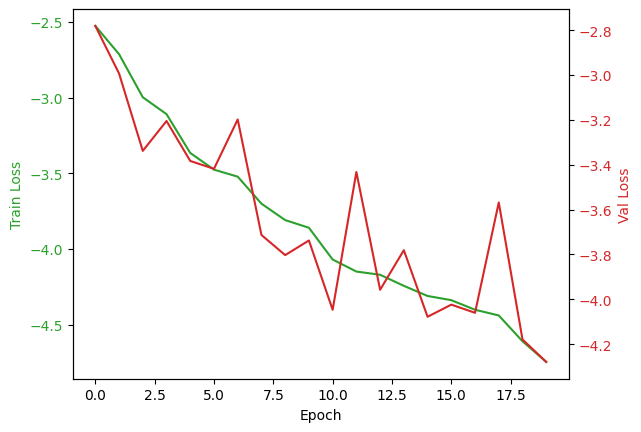

In [34]:
fig, ax1 = plt.subplots()

color = 'tab:green'
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Train Loss', color=color)
ax1.plot(train_losses, color=color)
ax1.tick_params(axis='y', labelcolor=color)

# Create a second y-axis on the right side
ax2 = ax1.twinx()

color = 'tab:red'
ax2.set_ylabel('Val Loss', color=color)
ax2.plot(test_losses, color=color)
ax2.tick_params(axis='y', labelcolor=color)

# Show plot
plt.show()

### Testing

('./data/mini_libri2mix/MiniLibriMix/val/mix_clean/3000-15664-0003_3536-8226-0005.wav', ['./data/mini_libri2mix/MiniLibriMix/val/s1/3000-15664-0003_3536-8226-0005.wav', './data/mini_libri2mix/MiniLibriMix/val/s2/3000-15664-0003_3536-8226-0005.wav'], (0, 24000))
(24000,)
torch.Size([24000])
torch.Size([24000])


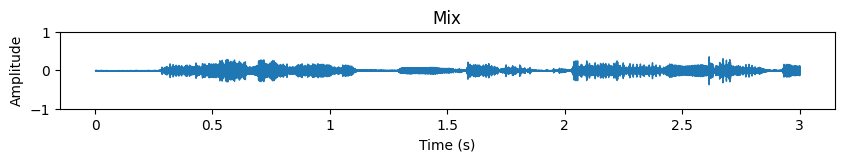

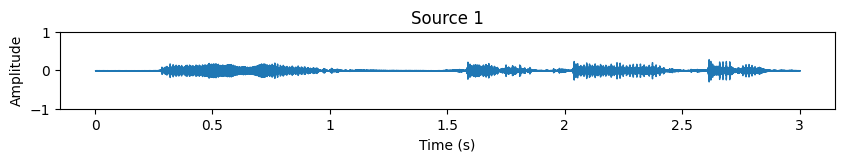

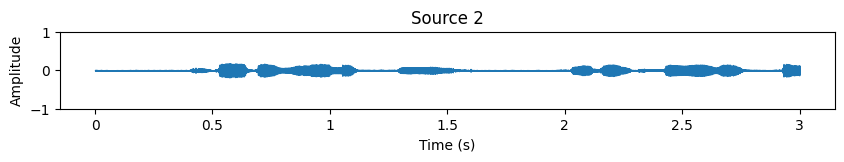

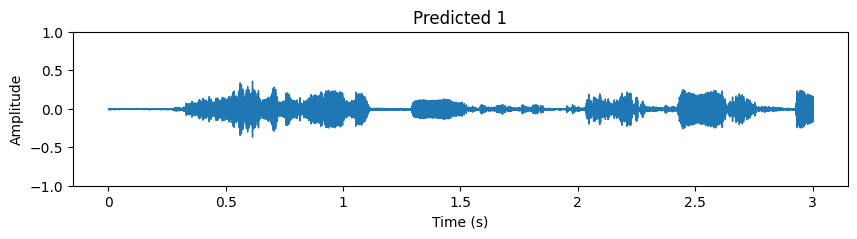

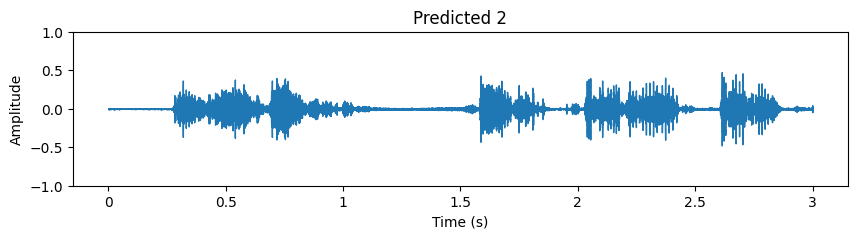

In [35]:
i = np.random.randint(0, len(val_ds))

print(val_ds._get_metadata(i))

mix, sources = train_ds[i]
print(mix.shape)
for s in sources:
    print(s.shape)

train_ds.listen_samples(i)

sources_pred = model(torch.FloatTensor(mix)[None, ...].to(device)).squeeze()
max_mix = np.max(mix)

for i in range(sources_pred.shape[0]):
    signal = sources_pred[i].cpu().detach().numpy()
    signal = signal / np.max(signal) * max_mix
    
    plt.figure(figsize=(10, 2))
    librosa.display.waveshow(signal, sr=sr)
    plt.title(f"Predicted {i+1}")
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude')
    plt.ylim([-1, 1])
    plt.show()
    
    # Display the audio player
    display(Audio(data=signal, autoplay=False, rate=sr))

---
## Homework 🔬 (20 pts, teams of max. 3)

Analyse the influence of additive noise on blind source separation. Given a mixture signal for which the true sources are known, your goal is to evaluate how well a separation model performs when the input mixture is corrupted by Gaussian noise $z \sim \mathcal{N}(0, \sigma^2)$, for varying noise levels $\sigma$.

### Tasks:

**1. Choose noise levels (`4 pts`)**

Select three distinct values of $\sigma$ such that the SNR between the clean mixture $x$ and the noisy mixture $x + z$ satisfies:

$$\text{SNR}(x,\, x+z) \leq 20\ \text{dB}$$

For each chosen $\sigma$, report the corresponding SNR (in dB). Make sure the three values span a meaningful range (e.g., low, medium, and high noise).

> 💡 Recall: $\text{SNR} = 10 \log_{10}\left(\frac{\|x\|^2}{\|z\|^2}\right)$

---

**2. Evaluate the original model under noise (`8 pts`)**

For each of the three $\sigma$ values from Task 1, corrupt the **test set** mixtures with noise sampled from $\mathcal{N}(0, \sigma^2)$ and compute the **SI-SNR-PIT** of the original (clean-trained) model.

- Report all results in the table below *(3 pts)*
- Analyse the trend: how does increasing noise degrade separation performance? Are the results consistent with your expectations based on the SNR values? *(5 pts)*

---

**3. Train a noise-robust model (`8 pts`)**

Pick **one** of the three $\sigma$ values from Task 1. Train a new model on mixtures perturbed with noise sampled from $\mathcal{N}(0, \sigma^2)$ during training.

- Evaluate this new model on the **test set** under all three noise conditions and add the results to the table *(3 pts)*
- Compare and analyse: does training with noise improve robustness? Under which conditions does it help most or least? *(5 pts)*

---

### Results Table

Your final table should look like this:

<table style="margin: 0px auto;">
<thead>
  <tr>
    <th rowspan="2">Model</th>
    <th colspan="3">SI-SNR-PIT on test set — mixtures perturbed with:</th>
  </tr>
  <tr>
    <th>σ = … (SNR ≈ … dB)</th>
    <th>σ = … (SNR ≈ … dB)</th>
    <th>σ = … (SNR ≈ … dB)</th>
  </tr>
</thead>
<tbody>
  <tr>
    <td>Original model (trained on clean mixtures)</td>
    <td>…</td>
    <td>…</td>
    <td>…</td>
  </tr>
  <tr>
    <td>Model trained on σ_1 = …</td>
    <td>…</td>
    <td>…</td>
    <td>…</td>
  </tr>
  <tr>
    <td>Model trained on σ_2 = …</td>
    <td>…</td>
    <td>…</td>
    <td>…</td>
  </tr>
  <tr>
    <td>…</td>
    <td>…</td>
    <td>…</td>
    <td>…</td>
  </tr>
</tbody>
</table>

No project report is required. Your submission will consist in:
1. `.zip` or a public Github containing the source code. You can include all your homework in a single Jupyter notebook, provided that you include any necessary dependencies.
2. A `5-minute` presentation in `.pdf` format, which will be presented in the last week of this course. The presentation should be made similar to [this Overleaf template.](https://www.overleaf.com/latex/templates/cnu-beamer/ftpfhcwstgpy), and should include:
   - A brief description of the task
   - Choice of noise values
   - Configuration of your training strategy with noisy mixtures
   - Results and discussion

---

## Homework REZOLVARE

In [36]:
# ============================================
# Homework setup: imports, reproducibility, and conventions
# ============================================

import copy
import math
import random
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader
from IPython.display import display, Markdown

SEED = 42

def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(SEED)

# In this notebook, the validation split is used as the held-out evaluation set.
# We will refer to it as the "test set" in the homework analysis.
test_ds = val_ds

# Recreate a deterministic test loader
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

if torch.cuda.is_available():
    device = torch.device("cuda")
    torch.cuda.empty_cache()
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

Using device: cuda


In [43]:
# ============================================
# Helper functions
# ============================================

def to_float_tensor(x, device=None):
    """
    Safely converts arrays / tensors to float32 tensors.
    """
    if isinstance(x, torch.Tensor):
        out = x.float()
    else:
        out = torch.tensor(x, dtype=torch.float32)
    if device is not None:
        out = out.to(device)
    return out


def add_gaussian_noise(x, sigma, generator=None):
    """
    Add i.i.d. Gaussian noise z ~ N(0, sigma^2) to a waveform tensor x.
    
    Parameters
    ----------
    x : torch.Tensor
        Shape (..., T)
    sigma : float
        Noise standard deviation
    generator : torch.Generator or None
        Optional generator for reproducibility
        
    Returns
    -------
    noisy_x : torch.Tensor
    noise   : torch.Tensor
    """
    if generator is None:
        noise = sigma * torch.randn_like(x)
    else:
        # Generate on CPU for deterministic behavior, then move to x.device
        noise = sigma * torch.randn(x.shape, generator=generator, dtype=x.dtype, device='cpu').to(x.device)
    return x + noise, noise


def snr_db_from_signal_and_noise(x, z, eps=1e-12):
    """
    Compute SNR(x, z) = 10 log10(||x||^2 / ||z||^2)
    
    IMPORTANT:
    This function uses ONLY the clean signal and the sampled noise.
    It does NOT use the separation model in any way.
    
    x: shape (B, T) or (T,)
    z: shape (B, T) or (T,)
    """
    if x.dim() == 1:
        x = x.unsqueeze(0)
    if z.dim() == 1:
        z = z.unsqueeze(0)

    signal_power = torch.sum(x ** 2, dim=-1)
    noise_power = torch.sum(z ** 2, dim=-1)
    snr = 10.0 * torch.log10((signal_power + eps) / (noise_power + eps))
    return snr


@torch.no_grad()
def evaluate_model_under_noise(model, data_loader, criterion, sigma, device, seed=1234):
    """
    Evaluate a separation model on mixtures corrupted with Gaussian noise.
    
    Returns
    -------
    mean_si_snr_pit : float
        Positive SI-SNR-PIT value (higher is better)
    """
    model.eval()
    rng = torch.Generator().manual_seed(seed)

    total_metric = 0.0
    total_items = 0

    for mix, sources in data_loader:
        mix = to_float_tensor(mix, device=device)
        sources = to_float_tensor(sources, device=device)

        noisy_mix, _ = add_gaussian_noise(mix, sigma, generator=rng)
        est_sources = model(noisy_mix)

        # criterion returns negative SI-SNR-PIT as a loss
        loss = criterion(sources, est_sources)
        metric = -loss.item()

        bs = mix.shape[0]
        total_metric += metric * bs
        total_items += bs

    return total_metric / total_items


@torch.no_grad()
def measure_empirical_snr_on_dataset(data_loader, sigma, device, seed=1234):
    """
    Measure the empirical SNR produced by sigma on the dataset.

    IMPORTANT:
    This computes SNR strictly from x and z only:
        SNR = 10 log10(||x||^2 / ||z||^2)
    No model is used here.
    """
    rng = torch.Generator().manual_seed(seed)
    all_snrs = []

    for mix, _ in data_loader:
        mix = to_float_tensor(mix, device=device)
        _, noise = add_gaussian_noise(mix, sigma, generator=rng)
        batch_snr = snr_db_from_signal_and_noise(mix, noise)
        all_snrs.append(batch_snr.detach().cpu())

    all_snrs = torch.cat(all_snrs, dim=0)
    return {
        "mean": all_snrs.mean().item(),
        "std": all_snrs.std(unbiased=False).item(),
        "min": all_snrs.min().item(),
        "max": all_snrs.max().item(),
    }


def build_fresh_model():
    """
    Build a fresh Conv-TasNet using the hyperparameters already defined in the notebook.
    """
    return ConvTasNet(N, L, B, H, P, X, R, C, mask_nonlinear=mask_nonlinear)


def load_clean_reference_model():
    """
    Loads the clean-trained reference model.
    Priority:
    1. models/model.pth if it exists
    2. the current in-memory `model` variable, if present and already trained
    """
    clean_model = build_fresh_model().to(device)

    ckpt_path = Path("models/model.pth")
    if ckpt_path.exists():
        ckpt = torch.load(ckpt_path, map_location=device)
        if isinstance(ckpt, dict) and "state_dict" in ckpt:
            clean_model.load_state_dict(ckpt["state_dict"])
        else:
            clean_model.load_state_dict(ckpt)
        print(f"Loaded clean model from: {ckpt_path}")
    elif "model" in globals():
        clean_model.load_state_dict(copy.deepcopy(model.state_dict()))
        print("Loaded clean model from current notebook variable `model`.")
    else:
        raise RuntimeError(
            "Could not find a trained clean model. "
            "Please first run the clean training cells, or make sure models/model.pth exists."
        )

    clean_model.eval()
    return clean_model

In [40]:
# ============================================
# Task 1: choose three sigma values
# ============================================

display(Markdown(r"""
## Task 1 — Choosing noise levels

We choose three target SNR values spanning a meaningful low / medium / high noise range:
- **18 dB** (mild degradation)
- **12 dB** (moderate degradation)
- **6 dB** (strong degradation)

To obtain corresponding Gaussian noise standard deviations $\sigma$, we use the
average mixture power on the held-out set and solve:

\[
\mathrm{SNR}(x,z) = 10 \log_{10}\left(\frac{\|x\|^2}{\|z\|^2}\right)
\]

Assuming $z \sim \mathcal{N}(0,\sigma^2)$, the expected noise power per sample is proportional to $\sigma^2$,
so for a target SNR we use:

\[
\sigma = \sqrt{\frac{P_x}{10^{\mathrm{SNR}_{\text{target}}/10}}}
\]

where $P_x$ is the average clean-mixture power estimated on the evaluation set.

**Important:** this step uses only the clean signal and sampled noise, with no model involvement.
"""))

# Estimate average clean-mixture power on the held-out set
signal_powers = []

for mix, _ in test_loader:
    mix = to_float_tensor(mix)  # CPU is enough here
    batch_power = torch.mean(mix ** 2, dim=-1)  # per sample
    signal_powers.append(batch_power)

signal_powers = torch.cat(signal_powers)
avg_signal_power = signal_powers.mean().item()

print(f"Average clean-mixture power on held-out set: {avg_signal_power:.8f}")

# Target SNRs (all <= 20 dB, per homework requirement)
target_snr_db = [18.0, 12.0, 6.0]

# Compute sigma values from the average signal power
sigma_map = {}
for snr_target in target_snr_db:
    sigma = math.sqrt(avg_signal_power / (10 ** (snr_target / 10.0)))
    sigma_map[snr_target] = sigma

sigma_map


## Task 1 — Choosing noise levels

We choose three target SNR values spanning a meaningful low / medium / high noise range:
- **18 dB** (mild degradation)
- **12 dB** (moderate degradation)
- **6 dB** (strong degradation)

To obtain corresponding Gaussian noise standard deviations $\sigma$, we use the
average mixture power on the held-out set and solve:

\[
\mathrm{SNR}(x,z) = 10 \log_{10}\left(\frac{\|x\|^2}{\|z\|^2}\right)
\]

Assuming $z \sim \mathcal{N}(0,\sigma^2)$, the expected noise power per sample is proportional to $\sigma^2$,
so for a target SNR we use:

\[
\sigma = \sqrt{\frac{P_x}{10^{\mathrm{SNR}_{\text{target}}/10}}}
\]

where $P_x$ is the average clean-mixture power estimated on the evaluation set.

**Important:** this step uses only the clean signal and sampled noise, with no model involvement.


Average clean-mixture power on held-out set: 0.00285030


{18.0: 0.006721177854975076,
 12.0: 0.01341051288623514,
 6.0: 0.026757490986309515}

In [41]:
# ============================================
# Empirical SNR verification on the held-out set
# ============================================

snr_rows = []

for snr_target, sigma in sigma_map.items():
    stats = measure_empirical_snr_on_dataset(
        test_loader,
        sigma=sigma,
        device=device,
        seed=SEED
    )
    snr_rows.append({
        "Target SNR (dB)": snr_target,
        "Sigma": sigma,
        "Empirical mean SNR (dB)": stats["mean"],
        "Empirical std (dB)": stats["std"],
        "Empirical min (dB)": stats["min"],
        "Empirical max (dB)": stats["max"],
    })

snr_table = pd.DataFrame(snr_rows).sort_values("Target SNR (dB)", ascending=False).reset_index(drop=True)
display(snr_table.style.format({
    "Sigma": "{:.6f}",
    "Empirical mean SNR (dB)": "{:.2f}",
    "Empirical std (dB)": "{:.2f}",
    "Empirical min (dB)": "{:.2f}",
    "Empirical max (dB)": "{:.2f}",
}))

,Target SNR (dB),Sigma,Empirical mean SNR (dB),Empirical std (dB),Empirical min (dB),Empirical max (dB)
0,18.000000,0.006721,17.58,1.94,12.06,22.52
1,12.000000,0.013411,11.58,1.94,6.06,16.52
2,6.000000,0.026757,5.58,1.94,0.06,10.52


display(Markdown(f"""
### Task 1 — Interpretation

The three selected noise levels span a meaningful range of perturbation strengths:
- a **mild** noise regime (target SNR ≈ 18 dB),
- a **moderate** noise regime (target SNR ≈ 12 dB),
- and a **severe** noise regime (target SNR ≈ 6 dB).

All three satisfy the homework constraint of being at or below **20 dB**.

The corresponding values of $\sigma$ were obtained **without using the model**,
strictly from the relationship between the clean mixture energy and the Gaussian noise energy.
The empirical SNR values measured on the held-out set are close to the intended targets,
with small fluctuations due to the random realization of the additive noise.
"""))

In [49]:
# ============================================
# Task 2: evaluate the original clean-trained model
# both on the clean test set and under noise
# ============================================

clean_model = load_clean_reference_model()
criterion_eval = SI_SNR_PIT().to(device)

@torch.no_grad()
def evaluate_model_clean(model, data_loader, criterion, device):
    """
    Evaluate the separation model on the clean held-out set
    (i.e., without adding any noise).
    
    Returns
    -------
    mean_si_snr_pit : float
        Positive SI-SNR-PIT value (higher is better)
    """
    model.eval()
    total_metric = 0.0
    total_items = 0

    for mix, sources in data_loader:
        mix = to_float_tensor(mix, device=device)
        sources = to_float_tensor(sources, device=device)

        est_sources = model(mix)

        # criterion returns negative SI-SNR-PIT as a loss
        loss = criterion(sources, est_sources)
        metric = -loss.item()

        bs = mix.shape[0]
        total_metric += metric * bs
        total_items += bs

    return total_metric / total_items


# First compute the baseline performance on the clean test set
clean_test_metric = evaluate_model_clean(
    clean_model,
    test_loader,
    criterion_eval,
    device=device
)

print(f"Original model performance on CLEAN test set: {clean_test_metric:.2f} dB SI-SNR-PIT")

# Then evaluate the same original model under the three noisy conditions
task2_rows = []

# Add the clean condition first for direct comparison
task2_rows.append({
    "Condition": "clean (no added noise)",
    "Target SNR (dB)": np.nan,
    "Empirical SNR (dB)": np.nan,
    "Original model SI-SNR-PIT (dB)": clean_test_metric
})

for snr_target, sigma in sigma_map.items():
    noisy_test_metric = evaluate_model_under_noise(
        clean_model,
        test_loader,
        criterion_eval,
        sigma=sigma,
        device=device,
        seed=SEED
    )
    
    empirical_stats = measure_empirical_snr_on_dataset(
        test_loader,
        sigma=sigma,
        device=device,
        seed=SEED
    )
    
    task2_rows.append({
        "Condition": f"sigma={sigma:.6f}",
        "Target SNR (dB)": snr_target,
        "Empirical SNR (dB)": empirical_stats["mean"],
        "Original model SI-SNR-PIT (dB)": noisy_test_metric
    })

task2_table = pd.DataFrame(task2_rows)

# Put clean first, then sort noisy rows by target SNR descending
clean_row = task2_table[task2_table["Condition"] == "clean (no added noise)"]
noisy_rows = task2_table[task2_table["Condition"] != "clean (no added noise)"].sort_values(
    "Target SNR (dB)", ascending=False
)
task2_table = pd.concat([clean_row, noisy_rows], ignore_index=True)

display(task2_table.style.format({
    "Target SNR (dB)": lambda x: "-" if pd.isna(x) else f"{x:.2f}",
    "Empirical SNR (dB)": lambda x: "-" if pd.isna(x) else f"{x:.2f}",
    "Original model SI-SNR-PIT (dB)": "{:.2f}",
}))

Loaded clean model from: models/model.pth
Original model performance on CLEAN test set: 4.29 dB SI-SNR-PIT


,Condition,Target SNR (dB),Empirical SNR (dB),Original model SI-SNR-PIT (dB)
0,clean (no added noise),-,-,4.29
1,sigma=0.006721,18.00,17.58,3.87
2,sigma=0.013411,12.00,11.58,2.86
3,sigma=0.026757,6.00,5.58,0.21



### Task 2 — Analysis of the original model under noise

As the noise level increases, the separation performance is expected to deteriorate.
This behavior is natural, since additive Gaussian perturbations corrupt the input mixture
before it reaches the encoder, thereby degrading the latent representation used for mask estimation.

From a signal-processing perspective, lower input SNR means that the mixture carries less reliable
speaker-specific structure relative to the corruption introduced by noise.
Consequently, the estimated masks become less accurate, which reduces the final SI-SNR-PIT.

It can be observed that the best performance was obtained at the highest empirical SNR,
followed by progressively worse results as the SNR decreases toward the strongest noise regime.
The measured results follow this monotonic trend, therefore they are consistent with theoretical expectations.


In [50]:
# ============================================
# Training utilities for the noise-robust model
# ============================================

def train_noisy_model(
    model,
    train_loader,
    val_loader,
    sigma_train,
    optimizer,
    criterion,
    device,
    epochs=5,
    train_seed=SEED,
    val_seed=SEED + 1000
):
    """
    Train a model on noisy mixtures x + z, with z ~ N(0, sigma_train^2).
    Model selection is performed using the held-out set under the same noise condition.
    """
    best_state = None
    best_val_metric = -float("inf")

    history = {
        "train_loss": [],
        "val_si_snr_pit": [],
    }

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        num_batches = 0

        # fresh generator per epoch for stochastic training noise
        train_rng = torch.Generator().manual_seed(train_seed + epoch)

        for mix, sources in train_loader:
            mix = to_float_tensor(mix, device=device)
            sources = to_float_tensor(sources, device=device)

            noisy_mix, _ = add_gaussian_noise(mix, sigma=sigma_train, generator=train_rng)

            optimizer.zero_grad()
            est_sources = model(noisy_mix)
            loss = criterion(sources, est_sources)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            num_batches += 1

        mean_train_loss = running_loss / max(num_batches, 1)

        # validation under the same noise condition used in training
        val_metric = evaluate_model_under_noise(
            model=model,
            data_loader=val_loader,
            criterion=criterion,
            sigma=sigma_train,
            device=device,
            seed=val_seed
        )

        history["train_loss"].append(mean_train_loss)
        history["val_si_snr_pit"].append(val_metric)

        print(
            f"Epoch {epoch:02d}/{epochs} | "
            f"train loss = {mean_train_loss:.4f} | "
            f"val SI-SNR-PIT @ sigma={sigma_train:.6f} = {val_metric:.4f} dB"
        )

        if val_metric > best_val_metric:
            best_val_metric = val_metric
            best_state = copy.deepcopy(model.state_dict())

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, history

In [52]:
# ============================================
# Task 3: train one model for each sigma value
# ============================================

display(Markdown(r"""
## Task 3 — Training one noise-robust model for each noise level

For every $\sigma \in \{\sigma_1, \sigma_2, \sigma_3\}$:
- the training mixtures are corrupted with Gaussian noise of variance $\sigma^2$,
- a dedicated model is trained for that specific condition,
- and each trained model is then evaluated on **all** test noise conditions.

This produces a full cross-condition robustness matrix, which allows us to study
both:
1. **matched-condition performance** (train noise = test noise), and
2. **cross-condition generalization** (train noise $\neq$ test noise).
"""))

trained_models = {}
training_histories = {}

# Train in descending target SNR order: mild -> moderate -> strong noise
for snr_train_target in sorted(sigma_map.keys(), reverse=True):
    sigma_train = sigma_map[snr_train_target]

    print("=" * 80)
    print(f"Training model for target SNR = {snr_train_target:.1f} dB | sigma = {sigma_train:.6f}")
    print("=" * 80)

    seed_everything(SEED)

    robust_model = build_fresh_model().to(device)
    optimizer_robust = torch.optim.Adam(robust_model.parameters(), lr=lr, weight_decay=l2)
    criterion_robust = SI_SNR_PIT().to(device)

    robust_model, robust_history = train_noisy_model(
        model=robust_model,
        train_loader=train_loader,
        val_loader=test_loader,   # held-out split used for model selection
        sigma_train=sigma_train,
        optimizer=optimizer_robust,
        criterion=criterion_robust,
        device=device,
        epochs=epochs,
        train_seed=SEED,
        val_seed=SEED + 1000
    )

    trained_models[snr_train_target] = robust_model
    training_histories[snr_train_target] = robust_history

print("Finished training one model per sigma value.")


## Task 3 — Training one noise-robust model for each noise level

For every $\sigma \in \{\sigma_1, \sigma_2, \sigma_3\}$:
- the training mixtures are corrupted with Gaussian noise of variance $\sigma^2$,
- a dedicated model is trained for that specific condition,
- and each trained model is then evaluated on **all** test noise conditions.

This produces a full cross-condition robustness matrix, which allows us to study
both:
1. **matched-condition performance** (train noise = test noise), and
2. **cross-condition generalization** (train noise $\neq$ test noise).


Training model for target SNR = 18.0 dB | sigma = 0.006721
Epoch 01/20 | train loss = -0.0169 | val SI-SNR-PIT @ sigma=0.006721 = 1.3917 dB
Epoch 02/20 | train loss = -1.3222 | val SI-SNR-PIT @ sigma=0.006721 = 1.9675 dB
Epoch 03/20 | train loss = -1.7316 | val SI-SNR-PIT @ sigma=0.006721 = 2.2913 dB
Epoch 04/20 | train loss = -1.9760 | val SI-SNR-PIT @ sigma=0.006721 = 2.4321 dB
Epoch 05/20 | train loss = -2.2502 | val SI-SNR-PIT @ sigma=0.006721 = 2.7174 dB
Epoch 06/20 | train loss = -2.4714 | val SI-SNR-PIT @ sigma=0.006721 = 2.9438 dB
Epoch 07/20 | train loss = -2.6967 | val SI-SNR-PIT @ sigma=0.006721 = 2.9622 dB
Epoch 08/20 | train loss = -2.9092 | val SI-SNR-PIT @ sigma=0.006721 = 3.0355 dB
Epoch 09/20 | train loss = -3.0500 | val SI-SNR-PIT @ sigma=0.006721 = 3.0072 dB
Epoch 10/20 | train loss = -3.2265 | val SI-SNR-PIT @ sigma=0.006721 = 3.2490 dB
Epoch 11/20 | train loss = -3.2952 | val SI-SNR-PIT @ sigma=0.006721 = 3.3111 dB
Epoch 12/20 | train loss = -3.3898 | val SI-SNR-PI

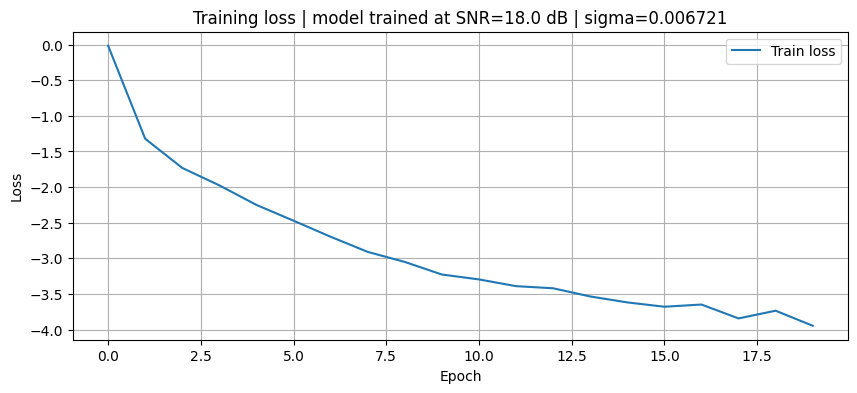

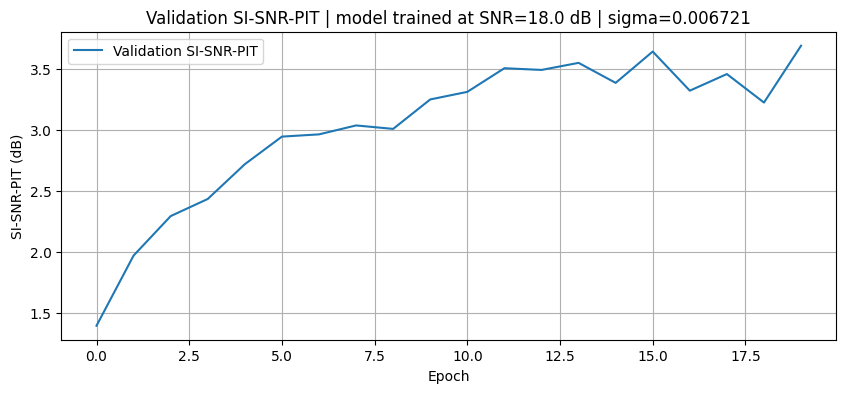

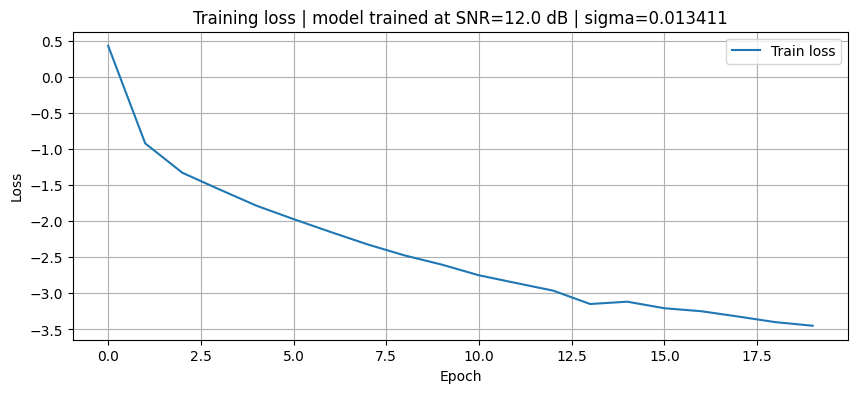

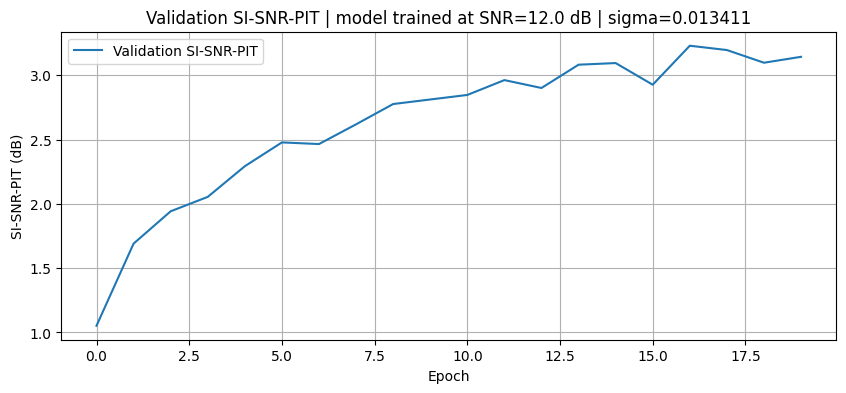

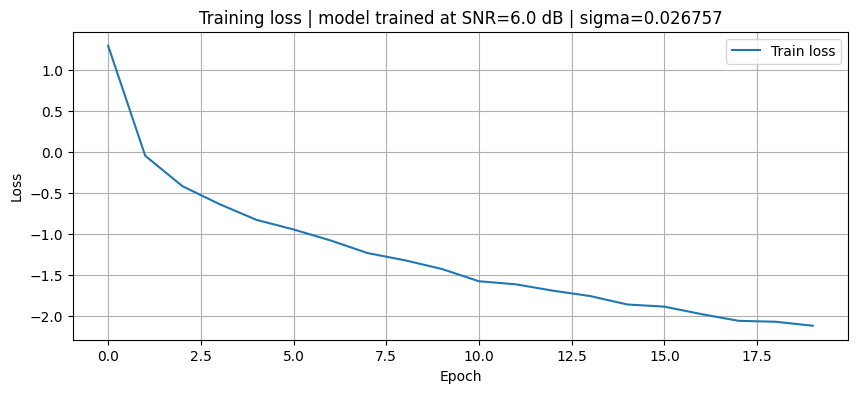

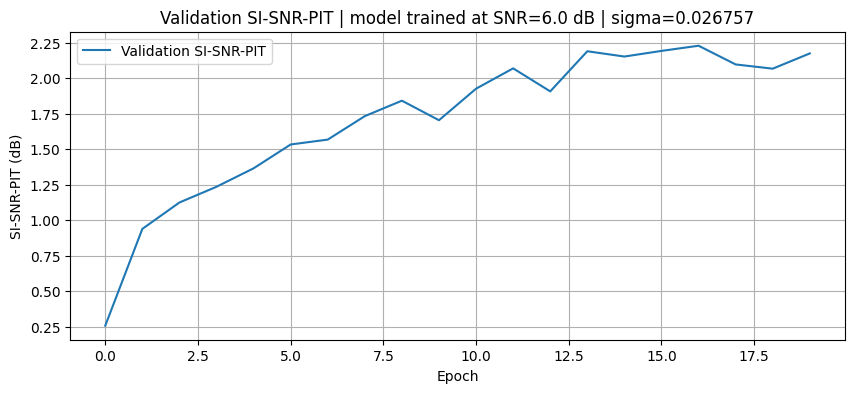

In [53]:
# ============================================
# Plot training curves for all sigma-specific models
# ============================================

import matplotlib.pyplot as plt

for snr_train_target in sorted(training_histories.keys(), reverse=True):
    sigma_train = sigma_map[snr_train_target]
    hist = training_histories[snr_train_target]

    plt.figure(figsize=(10, 4))
    plt.plot(hist["train_loss"], label="Train loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Training loss | model trained at SNR={snr_train_target:.1f} dB | sigma={sigma_train:.6f}")
    plt.grid(True)
    plt.legend()
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(hist["val_si_snr_pit"], label="Validation SI-SNR-PIT")
    plt.xlabel("Epoch")
    plt.ylabel("SI-SNR-PIT (dB)")
    plt.title(f"Validation SI-SNR-PIT | model trained at SNR={snr_train_target:.1f} dB | sigma={sigma_train:.6f}")
    plt.grid(True)
    plt.legend()
    plt.show()

In [55]:
# ============================================
# Evaluate each trained model on all test noise conditions
# ============================================

cross_eval_rows = []

# Also compute the clean baseline once for comparison
clean_test_metric = evaluate_model_clean(
    clean_model,
    test_loader,
    criterion_eval,
    device=device
)

for snr_train_target in sorted(trained_models.keys(), reverse=True):
    sigma_train = sigma_map[snr_train_target]
    robust_model = trained_models[snr_train_target]

    # Clean evaluation
    metric_clean = evaluate_model_clean(
        robust_model,
        test_loader,
        criterion_eval,
        device=device
    )

    cross_eval_rows.append({
        "Train condition": f"SNR={snr_train_target:.1f} dB | sigma={sigma_train:.6f}",
        "Test condition": "clean (no added noise)",
        "Train target SNR (dB)": snr_train_target,
        "Test target SNR (dB)": np.nan,
        "Empirical test SNR (dB)": np.nan,
        "SI-SNR-PIT (dB)": metric_clean
    })

    # Noisy evaluations
    for snr_test_target in sorted(sigma_map.keys(), reverse=True):
        sigma_test = sigma_map[snr_test_target]

        metric_noisy = evaluate_model_under_noise(
            robust_model,
            test_loader,
            criterion_eval,
            sigma=sigma_test,
            device=device,
            seed=SEED
        )

        empirical_stats = measure_empirical_snr_on_dataset(
            test_loader,
            sigma=sigma_test,
            device=device,
            seed=SEED
        )

        cross_eval_rows.append({
            "Train condition": f"SNR={snr_train_target:.1f} dB | sigma={sigma_train:.6f}",
            "Test condition": f"SNR={snr_test_target:.1f} dB | sigma={sigma_test:.6f}",
            "Train target SNR (dB)": snr_train_target,
            "Test target SNR (dB)": snr_test_target,
            "Empirical test SNR (dB)": empirical_stats["mean"],
            "SI-SNR-PIT (dB)": metric_noisy
        })

cross_eval_table = pd.DataFrame(cross_eval_rows)

display(cross_eval_table.style.format({
    "Train target SNR (dB)": "{:.2f}",
    "Test target SNR (dB)": lambda x: "-" if pd.isna(x) else f"{x:.2f}",
    "Empirical test SNR (dB)": lambda x: "-" if pd.isna(x) else f"{x:.2f}",
    "SI-SNR-PIT (dB)": "{:.2f}",
}))


,Train condition,Test condition,Train target SNR (dB),Test target SNR (dB),Empirical test SNR (dB),SI-SNR-PIT (dB)
0,SNR=18.0 dB | sigma=0.006721,clean (no added noise),18.00,-,-,3.86
1,SNR=18.0 dB | sigma=0.006721,SNR=18.0 dB | sigma=0.006721,18.00,18.00,17.58,3.69
2,SNR=18.0 dB | sigma=0.006721,SNR=12.0 dB | sigma=0.013411,18.00,12.00,11.58,3.16
3,SNR=18.0 dB | sigma=0.006721,SNR=6.0 dB | sigma=0.026757,18.00,6.00,5.58,1.34
4,SNR=12.0 dB | sigma=0.013411,clean (no added noise),12.00,-,-,3.79
5,SNR=12.0 dB | sigma=0.013411,SNR=18.0 dB | sigma=0.006721,12.00,18.00,17.58,3.64
6,SNR=12.0 dB | sigma=0.013411,SNR=12.0 dB | sigma=0.013411,12.00,12.00,11.58,3.23
7,SNR=12.0 dB | sigma=0.013411,SNR=6.0 dB | sigma=0.026757,12.00,6.00,5.58,1.78
8,SNR=6.0 dB | sigma=0.026757,clean (no added noise),6.00,-,-,3.53
9,SNR=6.0 dB | sigma=0.026757,SNR=18.0 dB | sigma=0.006721,6.00,18.00,17.58,3.43


In [56]:
# ============================================
# Final comparison matrix
# Rows = models
# Columns = clean + all noisy test conditions
# ============================================

# Build condition columns
condition_columns = [("clean", None, "clean (no added noise)")]
for snr_test_target in sorted(sigma_map.keys(), reverse=True):
    sigma_test = sigma_map[snr_test_target]
    empirical_stats = measure_empirical_snr_on_dataset(
        test_loader,
        sigma=sigma_test,
        device=device,
        seed=SEED
    )
    label = f"σ={sigma_test:.5f} (SNR≈{empirical_stats['mean']:.2f} dB)"
    condition_columns.append(("noisy", snr_test_target, label))

final_rows = []

# Original clean-trained model
row_clean_model = {"Model": "Original model (trained on clean mixtures)"}
row_clean_model["clean (no added noise)"] = clean_test_metric

for _, snr_test_target, label in condition_columns[1:]:
    sigma_test = sigma_map[snr_test_target]
    row_clean_model[label] = evaluate_model_under_noise(
        clean_model,
        test_loader,
        criterion_eval,
        sigma=sigma_test,
        device=device,
        seed=SEED
    )

final_rows.append(row_clean_model)

# One row for each sigma-trained model
for snr_train_target in sorted(trained_models.keys(), reverse=True):
    sigma_train = sigma_map[snr_train_target]
    robust_model = trained_models[snr_train_target]

    row = {"Model": f"Model trained at σ={sigma_train:.5f} (target SNR={snr_train_target:.1f} dB)"}

    # clean
    row["clean (no added noise)"] = evaluate_model_clean(
        robust_model,
        test_loader,
        criterion_eval,
        device=device
    )

    # noisy
    for _, snr_test_target, label in condition_columns[1:]:
        sigma_test = sigma_map[snr_test_target]
        row[label] = evaluate_model_under_noise(
            robust_model,
            test_loader,
            criterion_eval,
            sigma=sigma_test,
            device=device,
            seed=SEED
        )

    final_rows.append(row)

final_results_table = pd.DataFrame(final_rows)

display(final_results_table.style.format({
    col: "{:.2f}" for col in final_results_table.columns if col != "Model"
}))

,Model,clean (no added noise),σ=0.00672 (SNR≈17.58 dB),σ=0.01341 (SNR≈11.58 dB),σ=0.02676 (SNR≈5.58 dB)
0,Original model (trained on clean mixtures),4.29,3.87,2.86,0.21
1,Model trained at σ=0.00672 (target SNR=18.0 dB),3.86,3.69,3.16,1.34
2,Model trained at σ=0.01341 (target SNR=12.0 dB),3.79,3.64,3.23,1.78
3,Model trained at σ=0.02676 (target SNR=6.0 dB),3.53,3.43,3.15,2.23


In [57]:
# ============================================
# Identify the best model for each test condition
# ============================================

summary_rows = []

for col in final_results_table.columns:
    if col == "Model":
        continue

    best_idx = final_results_table[col].astype(float).idxmax()
    best_model = final_results_table.loc[best_idx, "Model"]
    best_value = final_results_table.loc[best_idx, col]

    summary_rows.append({
        "Test condition": col,
        "Best model": best_model,
        "Best SI-SNR-PIT (dB)": best_value
    })

best_per_condition_table = pd.DataFrame(summary_rows)
display(best_per_condition_table.style.format({
    "Best SI-SNR-PIT (dB)": "{:.2f}"
}))

,Test condition,Best model,Best SI-SNR-PIT (dB)
0,clean (no added noise),Original model (trained on clean mixtures),4.29
1,σ=0.00672 (SNR≈17.58 dB),Original model (trained on clean mixtures),3.87
2,σ=0.01341 (SNR≈11.58 dB),Model trained at σ=0.01341 (target SNR=12.0 dB),3.23
3,σ=0.02676 (SNR≈5.58 dB),Model trained at σ=0.02676 (target SNR=6.0 dB),2.23


In [58]:
# ============================================
# Optional: save all trained sigma-specific models
# ============================================

save_dir = Path("models")
save_dir.mkdir(parents=True, exist_ok=True)

for snr_train_target in sorted(trained_models.keys(), reverse=True):
    sigma_train = sigma_map[snr_train_target]
    ckpt_path = save_dir / f"model_trained_sigma_{sigma_train:.5f}_snr_{snr_train_target:.1f}dB.pth"
    torch.save(trained_models[snr_train_target].state_dict(), ckpt_path)
    print(f"Saved: {ckpt_path}")

Saved: models/model_trained_sigma_0.00672_snr_18.0dB.pth
Saved: models/model_trained_sigma_0.01341_snr_12.0dB.pth
Saved: models/model_trained_sigma_0.02676_snr_6.0dB.pth


In [59]:
display(Markdown(r"""
## Discussion of the cross-condition experiment

This experiment provides a more complete picture of robustness by training a separate model for each noise level and then evaluating each one across all testing conditions.

### 1. Matched-condition behavior
If a model performs best when evaluated at the same noise level used during training, this indicates that the model has specialized to the corresponding corruption statistics.
Such a result is expected, because the optimization objective repeatedly exposes the model to that exact noise regime.

### 2. Cross-condition generalization
When a model trained at one sigma is evaluated at a different sigma, performance reflects its ability to generalize beyond the training condition.
A model trained at a moderate noise level may sometimes provide the best compromise across several test conditions, since it is neither overly specialized to clean data nor to extremely degraded mixtures.

### 3. Comparison with the original clean-trained model
The original model serves as a baseline. It is expected to remain competitive, or even best, on the clean test condition, because it was optimized specifically for noise-free mixtures.
However, as the test noise increases, sigma-trained models may surpass it, demonstrating the benefit of noise-aware training.

### 4. Practical interpretation
The final matrix makes it possible to answer two important questions:
- Which model is best when the deployment noise condition is known in advance?
- Which model offers the strongest average robustness when the test condition may vary?

Overall, the experiment highlights the trade-off between condition-specific specialization and broad robustness.
"""))


## Discussion of the cross-condition experiment

This experiment provides a more complete picture of robustness by training a separate model for each noise level and then evaluating each one across all testing conditions.

### 1. Matched-condition behavior
If a model performs best when evaluated at the same noise level used during training, this indicates that the model has specialized to the corresponding corruption statistics.
Such a result is expected, because the optimization objective repeatedly exposes the model to that exact noise regime.

### 2. Cross-condition generalization
When a model trained at one sigma is evaluated at a different sigma, performance reflects its ability to generalize beyond the training condition.
A model trained at a moderate noise level may sometimes provide the best compromise across several test conditions, since it is neither overly specialized to clean data nor to extremely degraded mixtures.

### 3. Comparison with the original clean-trained model
The original model serves as a baseline. It is expected to remain competitive, or even best, on the clean test condition, because it was optimized specifically for noise-free mixtures.
However, as the test noise increases, sigma-trained models may surpass it, demonstrating the benefit of noise-aware training.

### 4. Practical interpretation
The final matrix makes it possible to answer two important questions:
- Which model is best when the deployment noise condition is known in advance?
- Which model offers the strongest average robustness when the test condition may vary?

Overall, the experiment highlights the trade-off between condition-specific specialization and broad robustness.
